# A/B Test Design and Analysis: Personalized Playlist Module

Designs and analyzes a randomized experiment answering one product question: **does a personalized-playlist module on the home screen lift 14-day retention for non-paying listeners?** Treatment shows the module; control keeps the existing recommendation page. The segment focus follows notebooks 03–05, where short-term churn concentrates in low-activity, non-paying users.

The dataset is a static snapshot, so the experiment is **simulated**: known treatment effects are injected on top of the real eligible population (`src/experiment_simulation.py`), and the analysis pipeline is judged by whether it recovers them. The workflow is the standard industry one — design doc, power analysis, randomization with a sample-ratio-mismatch gate, primary/secondary/guardrail readout, pitfall checks (peeking, multiple testing, novelty), segment drill-down, and a launch decision.

**Dependencies:** population defined in `sql/ab_test_population.sql` (on top of `sql/build_user_feature_table.sql`); statistics in `src/ab_testing.py`; effect injection in `src/experiment_simulation.py` (both unit-tested in `tests/`). The simulated dataset is exported to `data/experiment_results.csv.gz` by `python -m src.experiment_simulation` for downstream analyses.

## 1. Experiment Design

| Design element | Choice |
|---|---|
| **Business problem** | 14-day retention among non-paying listeners is ~45% — the weakest of any subscription tier — and low-activity users both churn the most and contribute the most churners (notebook 04). |
| **Hypothesis** | A personalized-playlist module helps users find relevant content faster → more return listening → higher 14-day retention. |
| **Population** | All non-paying (free + trial) users at the experiment start: 33,473 users. The ideal cohort — users who signed up in the days right before the start — is empty in this snapshot (minimum observed tenure is 18 days), so signup recency is kept as a covariate and drill-down segment instead of an eligibility filter (documented in `sql/ab_test_population.sql`). |
| **Randomization unit** | **User.** The primary metric is user-grain (retained yes/no per user), and the unit of randomization must match the unit of analysis: session-level assignment would show one user both experiences (contamination) and break the independence assumption behind the z-test. |
| **Treatment / Control** | Treatment: personalized-playlist module on the home screen. Control: existing recommendation page. 50/50 split. |
| **Duration** | Exposure runs 14 days; the primary metric then needs **14 further days to mature** (a user exposed on the last enrollment day must still be observed for a full retention window). No readout before the window completes — section 8.1 quantifies what daily peeking would cost. |

**Metric hierarchy** — an experiment is never judged on one conversion rate:

| Metric | Role | Definition (14-day post-exposure window) | Desired direction |
|---|---|---|---|
| Retention | **Primary** | Listened at least once in the 14 days after exposure | ↑ |
| Listen minutes / user | Secondary | Total listening minutes | ↑ |
| Active days / user | Secondary | Days with listening activity | ↑ |
| Playlist add rate | Secondary | Added ≥ 1 track to a playlist | ↑ |
| Skip rate | **Guardrail** | Share of plays skipped (among retained users) | must not rise |
| Trial cancel rate | **Guardrail** | Canceled the trial (trial users only) | must not rise |
| Ad revenue / user | **Guardrail** | Ad revenue in USD | must not fall |

Secondary metrics explain *why* the primary moved; guardrails catch wins that quietly damage the experience or the business.

## 2. Data Loading

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or STREAMING_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RANDOM_SEED
from src.ab_testing import (
    MetricSpec,
    minimum_detectable_effect,
    peeking_false_positive_rate,
    proportion_ztest,
    required_sample_size,
    sequential_pvalues,
    srm_check,
    summarize_experiment,
)
from src.experiment_simulation import (
    SEGMENT_UPLIFT_PP,
    load_eligible_population,
    simulate_experiment,
    simulate_novelty_trajectory,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

CONTROL_COLOR = "#1f77b4"
TREATMENT_COLOR = "#ff7f0e"
NEUTRAL_COLOR = "#7f7f7f"
ALERT_COLOR = "#d62728"

population = load_eligible_population()
baseline_retention = 1 - population["churn_label_14d"].mean()
print(f"Eligible users: {len(population):,}")
print(f"Baseline 14-day retention: {baseline_retention:.1%}")
population.head()

Loaded tables: users, listening_events, subscription_events, ad_events, feature_table


Eligible users: 33,473
Baseline 14-day retention: 45.5%


,user_id,current_subscription_type,tenure_days,active_days_30d,listen_minutes_30d,skip_rate_30d,playlist_adds_30d,ad_revenue_30d,cancel_count_30d,churn_label_14d
0,U000002,trial,25,10,21.55,0.20,1,0.0544,0,1
1,U000003,trial,246,3,6.50,0.00,0,0.0025,0,1
2,U000004,trial,138,4,11.33,0.25,0,0.0703,0,0
3,U000005,free,315,1,2.72,0.00,0,0.0000,0,0
4,U000006,trial,23,3,32.63,0.00,0,0.0671,0,0


## 3. Power Analysis

Before running anything: is this population even large enough? The design targets a **minimum detectable effect (MDE) of +2.0pp** on the retention baseline at α = 0.05 (two-sided) and 80% power — smaller lifts are below the launch bar for this product surface anyway.

In [2]:
ALPHA, POWER, MDE_TARGET_PP = 0.05, 0.80, 2.0

n_required = required_sample_size(baseline_retention, MDE_TARGET_PP, ALPHA, POWER)
n_available = len(population) // 2
mde_achievable = minimum_detectable_effect(n_available, baseline_retention, ALPHA, POWER)

print(f"Required per arm for +{MDE_TARGET_PP:.0f}pp: {n_required:,} users")
print(f"Available per arm (50/50 split):  {n_available:,} users")
print(f"MDE at the available sample size: {mde_achievable:.2f}pp")

Required per arm for +2pp: 9,762 users
Available per arm (50/50 split):  16,736 users
MDE at the available sample size: 1.53pp


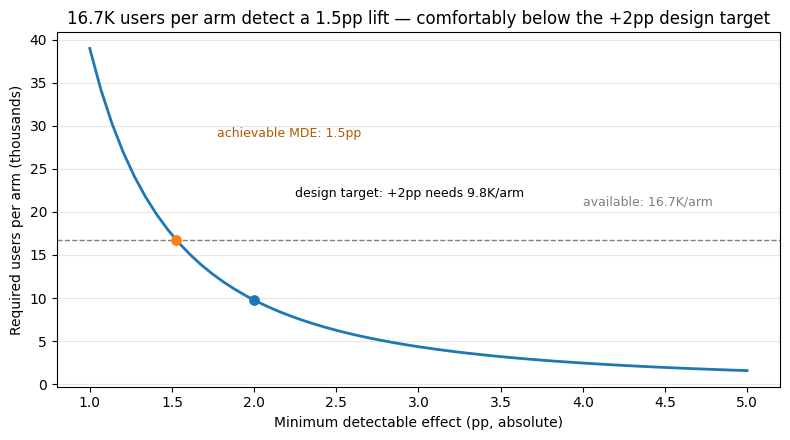

In [3]:
mde_grid = np.linspace(1.0, 5.0, 60)
n_curve = np.array([required_sample_size(baseline_retention, m, ALPHA, POWER)
                    for m in mde_grid])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mde_grid, n_curve / 1000, color=CONTROL_COLOR, linewidth=2)
ax.axhline(n_available / 1000, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.annotate(f"available: {n_available/1000:.1f}K/arm",
            xy=(4.0, n_available / 1000), xytext=(4.0, n_available / 1000 + 4),
            fontsize=9, color=NEUTRAL_COLOR)
ax.scatter([MDE_TARGET_PP], [n_required / 1000], color=CONTROL_COLOR, zorder=3, s=45)
ax.annotate(f"design target: +2pp needs {n_required/1000:.1f}K/arm",
            xy=(MDE_TARGET_PP, n_required / 1000),
            xytext=(MDE_TARGET_PP + 0.25, n_required / 1000 + 12), fontsize=9)
ax.scatter([mde_achievable], [n_available / 1000], color=TREATMENT_COLOR, zorder=3, s=45)
ax.annotate(f"achievable MDE: {mde_achievable:.1f}pp",
            xy=(mde_achievable, n_available / 1000),
            xytext=(mde_achievable + 0.25, n_available / 1000 + 12),
            fontsize=9, color="#b35900")
ax.set_xlabel("Minimum detectable effect (pp, absolute)")
ax.set_ylabel("Required users per arm (thousands)")
ax.set_title(f"{n_available/1000:.1f}K users per arm detect a {mde_achievable:.1f}pp lift — "
             f"comfortably below the +{MDE_TARGET_PP:.0f}pp design target")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Randomization and the SRM Gate

Users are randomized 50/50 at the user level with the project seed, and post-period outcomes are generated with the documented injected effects. **Before reading any metric**, two data-quality checks gate the analysis:

1. **Sample-ratio mismatch (SRM):** do arm sizes match the designed 50/50 split? A failure (p < 0.001) means assignment, logging, or eligibility is broken — in that case no result below can be trusted, so the notebook hard-stops.
2. **Covariate balance:** pre-experiment behavior should look identical across arms; randomization guarantees this in expectation.

In [4]:
results = simulate_experiment(population, treatment_share=0.5, seed=RANDOM_SEED)

n_control = int((results["group"] == "control").sum())
n_treatment = int((results["group"] == "treatment").sum())
srm = srm_check(n_control, n_treatment, expected_ratio=0.5)
print(f"Arms: control={n_control:,}, treatment={n_treatment:,}")
print(f"SRM check: chi2={srm.chi2:.3f}, p={srm.p_value:.3f} -> "
      f"{'PASS' if srm.passed else 'FAIL'}")

if not srm.passed:
    raise RuntimeError(
        f"SRM detected (p={srm.p_value:.2e} < {srm.p_threshold}): investigate "
        "assignment, logging, and eligibility before reading any result."
    )

Arms: control=16,814, treatment=16,659
SRM check: chi2=0.718, p=0.397 -> PASS


In [5]:
balance_covariates = ["tenure_days", "active_days_30d", "listen_minutes_30d",
                      "skip_rate_30d", "playlist_adds_30d", "ad_revenue_30d"]
by_arm = results.groupby("group")[balance_covariates].mean().T
pooled_std = results[balance_covariates].std()
by_arm["smd"] = (by_arm["treatment"] - by_arm["control"]) / pooled_std
print("Pre-experiment covariate balance (SMD < 0.02 everywhere -> balanced):")
by_arm.round(4)

Pre-experiment covariate balance (SMD < 0.02 everywhere -> balanced):


group,control,treatment,smd
tenure_days,210.9333,209.8116,-0.0096
active_days_30d,5.3278,5.4026,0.0139
listen_minutes_30d,31.2782,31.3589,0.0018
skip_rate_30d,0.1737,0.1767,0.0128
playlist_adds_30d,0.3595,0.3687,0.0100
ad_revenue_30d,0.0601,0.0607,0.0068


## 5. Primary Metric: 14-Day Retention

One primary metric, decided in advance, judged with an effect size and confidence interval — not a bare p-value. Ground truth for this simulation: the injected effect is **+2.2pp** population-weighted, so the pipeline should recover roughly that.

In [6]:
control = results[results["group"] == "control"]
treatment = results[results["group"] == "treatment"]

primary = proportion_ztest(
    int(control["retained_14d_post"].sum()), len(control),
    int(treatment["retained_14d_post"].sum()), len(treatment),
)
print(f"Control retention:   {primary.control_value:.2%}")
print(f"Treatment retention: {primary.treatment_value:.2%}")
print(f"Absolute lift: {primary.lift_abs*100:+.2f}pp "
      f"(95% CI [{primary.ci_low*100:+.2f}, {primary.ci_high*100:+.2f}]pp)")
print(f"Relative lift: {primary.lift_rel:+.1%}")
print(f"z = {primary.statistic:.2f}, p = {primary.p_value:.2e}")

Control retention:   45.26%
Treatment retention: 47.84%
Absolute lift: +2.58pp (95% CI [+1.51, +3.64]pp)
Relative lift: +5.7%
z = 4.72, p = 2.31e-06


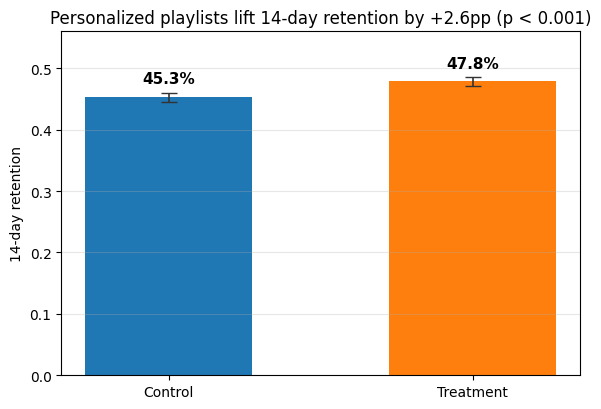

In [7]:
rates = [primary.control_value, primary.treatment_value]
ns = [len(control), len(treatment)]
half_widths = [1.96 * np.sqrt(p * (1 - p) / n) for p, n in zip(rates, ns)]

fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(["Control", "Treatment"], rates,
              yerr=half_widths, capsize=6,
              color=[CONTROL_COLOR, TREATMENT_COLOR], width=0.55,
              error_kw={"ecolor": "#333333", "elinewidth": 1.2})
for bar, rate in zip(bars, rates):
    ax.annotate(f"{rate:.1%}", xy=(bar.get_x() + bar.get_width() / 2, rate),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 0.56)
ax.set_ylabel("14-day retention")
ax.set_title(f"Personalized playlists lift 14-day retention by "
             f"{primary.lift_abs*100:+.1f}pp (p < 0.001)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The measured **+2.58pp** sits within sampling error of the injected +2.2pp truth (the 95% CI [+1.5, +3.6]pp covers it) — the pipeline recovers the known effect. Statistically this is about as clean as a primary readout gets. Whether it should *launch* is a different question, settled by the guardrails below.

## 6. Secondary Metrics

Secondary metrics explain the behavioral chain behind the primary move: are treated users actually listening more, coming back more often, engaging with the module's core action?

In [8]:
SECONDARY_METRICS = [
    MetricSpec("listen_minutes_14d", "listen_minutes_14d_post", "mean", "secondary", "increase"),
    MetricSpec("active_days_14d", "active_days_14d_post", "mean", "secondary", "increase"),
    MetricSpec("playlist_add_rate_14d", "playlist_added_14d_post", "proportion", "secondary", "increase"),
]
secondary_scorecard = summarize_experiment(results, SECONDARY_METRICS)
secondary_scorecard.round(4)

,metric,role,control,treatment,lift_abs,lift_rel,ci_low,ci_high,p_value,significant,healthy
0,listen_minutes_14d,secondary,10.3200,11.3764,1.0564,0.1024,0.5691,1.5437,0.0,True,True
1,active_days_14d,secondary,1.7066,1.8730,0.1665,0.0976,0.1069,0.2261,0.0,True,True
2,playlist_add_rate_14d,secondary,0.0846,0.0981,0.0135,0.1590,0.0073,0.0196,0.0,True,True


All three move up decisively: minutes **+10.2%**, active days **+9.8%**, playlist-add rate **+15.9%** (all p < 0.001). The engagement lift exceeds the injected per-user +6.5% on minutes because retention rescues *compound* it — users who would have left now contribute post-period listening. The behavioral chain backs the hypothesis.

## 7. Guardrail Metrics

Guardrails are one-sided "do no harm" checks. A primary win with a broken guardrail is not a launchable result.

In [9]:
GUARDRAIL_METRICS = [
    MetricSpec("skip_rate_14d", "skip_rate_14d_post", "mean", "guardrail", "decrease"),
    MetricSpec("trial_cancel_rate_14d", "cancel_14d_post", "proportion", "guardrail", "decrease"),
    MetricSpec("ad_revenue_14d", "ad_revenue_14d_post", "mean", "guardrail", "increase"),
]
guardrail_scorecard = summarize_experiment(results, GUARDRAIL_METRICS)
guardrail_scorecard.round(4)

,metric,role,control,treatment,lift_abs,lift_rel,ci_low,ci_high,p_value,significant,healthy
0,skip_rate_14d,guardrail,0.1825,0.2063,0.0237,0.1300,0.0177,0.0298,0.0000,True,False
1,trial_cancel_rate_14d,guardrail,0.0114,0.0129,0.0014,0.1254,-0.0018,0.0046,0.3785,False,True
2,ad_revenue_14d,guardrail,0.0178,0.0190,0.0012,0.0673,0.0003,0.0021,0.0090,True,True


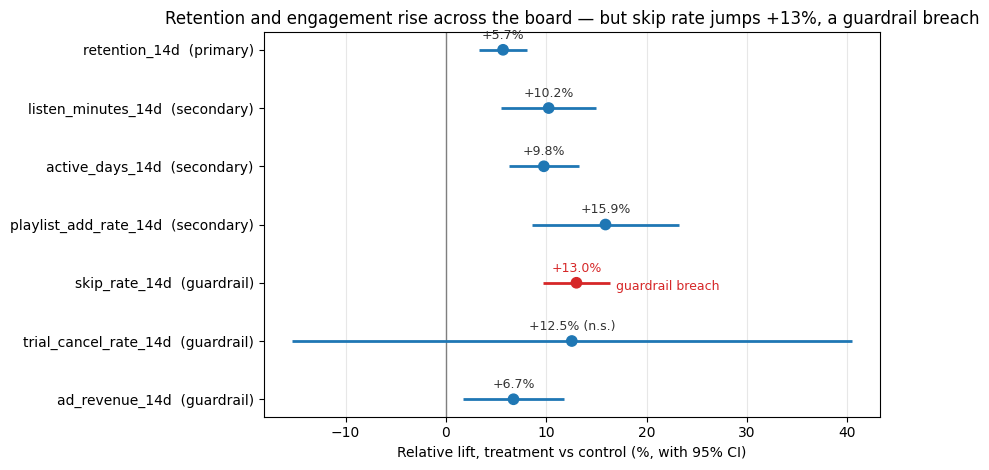

In [10]:
scorecard = pd.concat(
    [summarize_experiment(results, [MetricSpec("retention_14d", "retained_14d_post",
                                               "proportion", "primary", "increase")]),
     secondary_scorecard, guardrail_scorecard],
    ignore_index=True,
)

plot_df = scorecard.iloc[::-1]  # primary on top
rel_lift = plot_df["lift_rel"] * 100
rel_low = plot_df["ci_low"] / plot_df["control"] * 100
rel_high = plot_df["ci_high"] / plot_df["control"] * 100
colors = [ALERT_COLOR if not h else CONTROL_COLOR for h in plot_df["healthy"]]
labels = [f"{m}  ({r})" for m, r in zip(plot_df["metric"], plot_df["role"])]

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(plot_df))
ax.axvline(0, color=NEUTRAL_COLOR, linewidth=1)
ax.hlines(y, rel_low.to_numpy(), rel_high.to_numpy(), color=colors, linewidth=2)
ax.scatter(rel_lift.to_numpy(), y, color=colors, s=55, zorder=3)
for yi, x, healthy, sig in zip(y, rel_lift, plot_df["healthy"], plot_df["significant"]):
    label = f"{x:+.1f}%" + ("" if sig else " (n.s.)")
    ax.annotate(label, xy=(x, yi), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9,
                color=ALERT_COLOR if not healthy else "#333333")
for yi, healthy, hi in zip(y, plot_df["healthy"], rel_high):
    if not healthy:
        ax.annotate("guardrail breach", xy=(hi, yi), xytext=(hi + 0.6, yi - 0.06),
                    fontsize=9, color=ALERT_COLOR, va="center")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Relative lift, treatment vs control (%, with 95% CI)")
ax.set_title("Retention and engagement rise across the board — "
             "but skip rate jumps +13%, a guardrail breach")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The scorecard splits three ways:

- **Skip rate: breached.** 18.3% → 20.6% (+2.4pp, **+13% relative**, p < 0.001). The module drives more listening, but a meaningful share of what it recommends gets skipped — recommendation quality is not good enough yet. (The measured +2.4pp is slightly below the injected +3.0pp because rescued users are disproportionately low-skip listeners — a composition effect worth recognizing in real experiments too.)
- **Trial cancel rate: flat** (+0.14pp, p = 0.38) — no evidence the module pushes trial users away.
- **Ad revenue: up** (+6.7%, p = 0.009) — mechanically follows retention: more retained free users hear more ads.

## 8. Experimentation Pitfalls

Three ways this same experiment could have produced a wrong conclusion, each quantified on this data.

### 8.1 Peeking: reading the experiment before it matures

The design says: wait out the full retention window. What if we had checked daily and stopped at the first p < 0.05? Under A/A conditions (no true effect), each interim look is another chance for noise to cross the threshold.

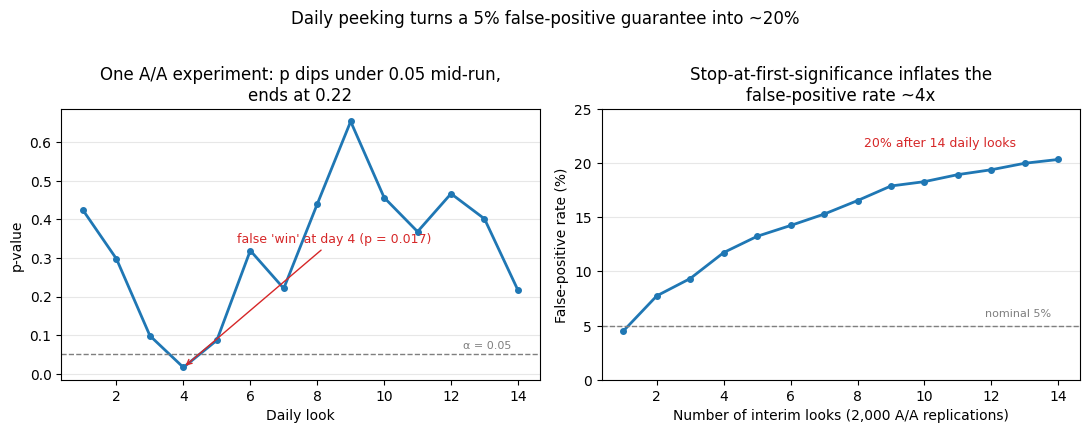

In [11]:
aa_rng = np.random.default_rng(15)  # illustrative A/A run
aa_control = (aa_rng.random(16_000) < baseline_retention).astype(int)
aa_treatment = (aa_rng.random(16_000) < baseline_retention).astype(int)
trajectory = sequential_pvalues(aa_control, aa_treatment, n_looks=14)

fpr = peeking_false_positive_rate(
    n_per_arm=n_treatment, true_rate=baseline_retention,
    n_looks=14, n_simulations=2_000, seed=RANDOM_SEED,
)
final_fpr = fpr["false_positive_rate"].iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.plot(trajectory["look"].to_numpy(), trajectory["p_value"].to_numpy(),
        marker="o", markersize=4, color=CONTROL_COLOR, linewidth=2)
ax.axhline(0.05, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
dip = trajectory.loc[trajectory["p_value"].idxmin()]
ax.annotate(f"false 'win' at day {int(dip['look'])} (p = {dip['p_value']:.3f})",
            xy=(dip["look"], dip["p_value"]), xytext=(dip["look"] + 1.6, 0.34),
            fontsize=9, color=ALERT_COLOR,
            arrowprops={"arrowstyle": "->", "color": ALERT_COLOR})
ax.text(13.8, 0.065, "α = 0.05", ha="right", fontsize=8, color=NEUTRAL_COLOR)
ax.set_xlabel("Daily look")
ax.set_ylabel("p-value")
ax.set_title("One A/A experiment: p dips under 0.05 mid-run,\nends at 0.22")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.plot(fpr["looks"].to_numpy(), (fpr["false_positive_rate"] * 100).to_numpy(),
        marker="o", markersize=4, color=CONTROL_COLOR, linewidth=2)
ax.axhline(5, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.text(13.8, 5.8, "nominal 5%", ha="right", fontsize=8, color=NEUTRAL_COLOR)
ax.annotate(f"{final_fpr:.0%} after 14 daily looks",
            xy=(14, final_fpr * 100), xytext=(8.2, final_fpr * 100 + 1.2),
            fontsize=9, color=ALERT_COLOR)
ax.set_xlabel("Number of interim looks (2,000 A/A replications)")
ax.set_ylabel("False-positive rate (%)")
ax.set_title("Stop-at-first-significance inflates the\nfalse-positive rate ~4x")
ax.set_ylim(0, 25)
ax.grid(axis="y", alpha=0.3)
fig.suptitle("Daily peeking turns a 5% false-positive guarantee into ~20%",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

A non-significant result read *once at maturity* is trustworthy; the same experiment read daily gives noise fourteen chances to masquerade as a win. If interim decisions are genuinely needed, use methods that price them in (group-sequential alpha-spending boundaries or always-valid inference) — not repeated fixed-horizon tests.

### 8.2 Multiple testing: significance shopping across segments

Slicing the readout by 10 segments × 5 metrics = 50 tests. To show what pure chance produces, the test below **permutes the group labels** — destroying every real effect — and runs all 50 tests on the resulting null data, then applies the Benjamini-Hochberg false-discovery-rate correction.

50 segment x metric tests on label-permuted (null) data
Naive p < 0.05:        6  (expected by chance: 2.5)
After Benjamini-Hochberg: 0


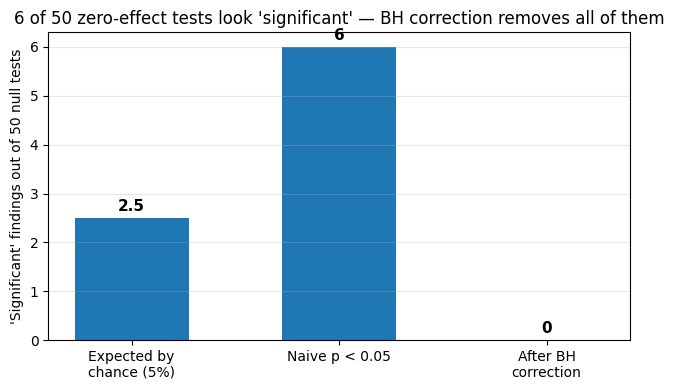

In [12]:
perm_rng = np.random.default_rng(RANDOM_SEED)
null_results = results.copy()
null_results["group"] = perm_rng.permutation(null_results["group"].to_numpy())
null_results["tenure_bucket"] = pd.qcut(null_results["tenure_days"], 4,
                                        labels=["q1", "q2", "q3", "q4"])

NULL_METRICS = [
    MetricSpec("retention_14d", "retained_14d_post", "proportion", "primary", "increase"),
    *SECONDARY_METRICS,
    MetricSpec("ad_revenue_14d", "ad_revenue_14d_post", "mean", "guardrail", "increase"),
]
segment_defs = (
    [("effect_segment", v) for v in sorted(null_results["effect_segment"].unique())]
    + [("current_subscription_type", v) for v in ["free", "trial"]]
    + [("tenure_bucket", v) for v in ["q1", "q2", "q3", "q4"]]
)

null_pvalues = []
for col, val in segment_defs:
    seg_scorecard = summarize_experiment(null_results[null_results[col] == val],
                                         NULL_METRICS)
    null_pvalues.extend(seg_scorecard["p_value"])
null_pvalues = np.array(null_pvalues)

from statsmodels.stats.multitest import multipletests
bh_rejected, _, _, _ = multipletests(null_pvalues, alpha=0.05, method="fdr_bh")

n_tests = len(null_pvalues)
naive_hits = int((null_pvalues < 0.05).sum())
bh_hits = int(bh_rejected.sum())
print(f"{n_tests} segment x metric tests on label-permuted (null) data")
print(f"Naive p < 0.05:        {naive_hits}  (expected by chance: {n_tests * 0.05:.1f})")
print(f"After Benjamini-Hochberg: {bh_hits}")

fig, ax = plt.subplots(figsize=(6.5, 4))
counts = [n_tests * 0.05, naive_hits, bh_hits]
bars = ax.bar(["Expected by\nchance (5%)", "Naive p < 0.05", "After BH\ncorrection"],
              counts, color=CONTROL_COLOR, width=0.55)
for bar, v in zip(bars, counts):
    ax.annotate(f"{v:.1f}" if v % 1 else f"{int(v)}",
                xy=(bar.get_x() + bar.get_width() / 2, v), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel(f"'Significant' findings out of {n_tests} null tests")
ax.set_title(f"{naive_hits} of {n_tests} zero-effect tests look 'significant' — "
             "BH correction removes all of them")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Six "discoveries" out of fifty tests where the true effect is exactly zero — slightly worse than the 2.5 expected at α = 0.05, and every one of them survives a plausible-sounding story ("trial users in their second tenure quartile respond strongly…"). Discipline: segments are **hypothesis-generating**, the pre-registered primary metric decides, and any segment claim promoted to a decision gets FDR control or its own confirmatory experiment.

### 8.3 Novelty effect: week 1 flatters the treatment

Users interact with a new module partly because it is new. The trajectory below simulates the weekly engagement lift with a decaying novelty component (week-1 truth +12% decaying to a +5% long run).

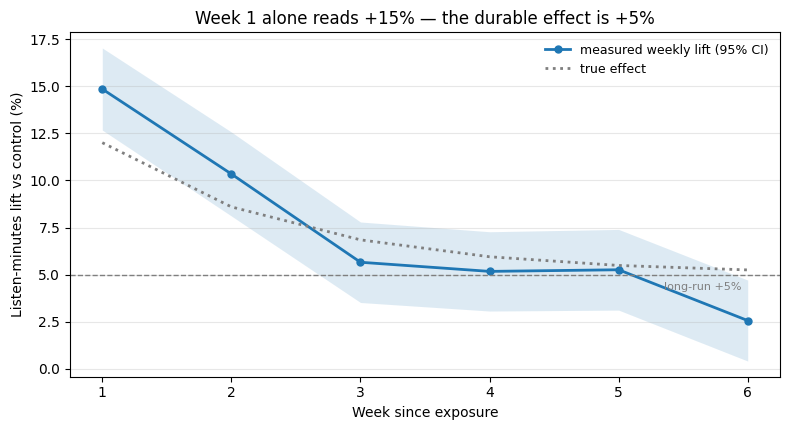

In [13]:
control_weekly_minutes = control["listen_minutes_14d_post"].mean() / 2
novelty = simulate_novelty_trajectory(
    n_per_arm=n_treatment, mean_weekly_minutes=control_weekly_minutes,
    n_weeks=6, seed=RANDOM_SEED,
)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.fill_between(novelty["week"].to_numpy(),
                (novelty["rel_lift_ci_low"] * 100).to_numpy(),
                (novelty["rel_lift_ci_high"] * 100).to_numpy(),
                color=CONTROL_COLOR, alpha=0.15, linewidth=0)
ax.plot(novelty["week"].to_numpy(), (novelty["rel_lift"] * 100).to_numpy(),
        marker="o", markersize=5, color=CONTROL_COLOR, linewidth=2,
        label="measured weekly lift (95% CI)")
ax.plot(novelty["week"].to_numpy(), (novelty["true_rel_lift"] * 100).to_numpy(),
        linestyle=":", color=NEUTRAL_COLOR, linewidth=2, label="true effect")
ax.axhline(5, color=NEUTRAL_COLOR, linestyle="--", linewidth=1)
ax.text(5.95, 4.2, "long-run +5%", ha="right", fontsize=8, color=NEUTRAL_COLOR)
ax.set_xlabel("Week since exposure")
ax.set_ylabel("Listen-minutes lift vs control (%)")
ax.set_title("Week 1 alone reads +15% — the durable effect is +5%")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Shipping on the week-1 number (+15% measured against a +5% durable effect) would bake a ~3x overstatement into the business case. Countermeasures: run long enough for the trajectory to flatten, compare late-window vs early-window effects before extrapolating, and re-measure post-launch on a holdback.

## 9. Segment Drill-Down and the Launch Decision

The primary result is significant — but the skip-rate guardrail is breached, so the next question is *where* the win and the harm live. The drill-down uses the four pre-registered behavioral segments; because the simulation stores each user's ground-truth uplift, the measured segment effects can be compared against the truth.

      segment  n_users  measured_lift_pp  ci_low_pp  ci_high_pp  p_value  true_uplift_pp
 low_activity    10597             4.354      2.666       6.042    0.000             5.0
 mid_activity    11800             1.772     -0.031       3.576    0.054             2.2
high_activity     6077             2.161      0.335       3.987    0.020             0.5
 high_skipper     4999            -0.278     -2.955       2.399    0.839            -1.5


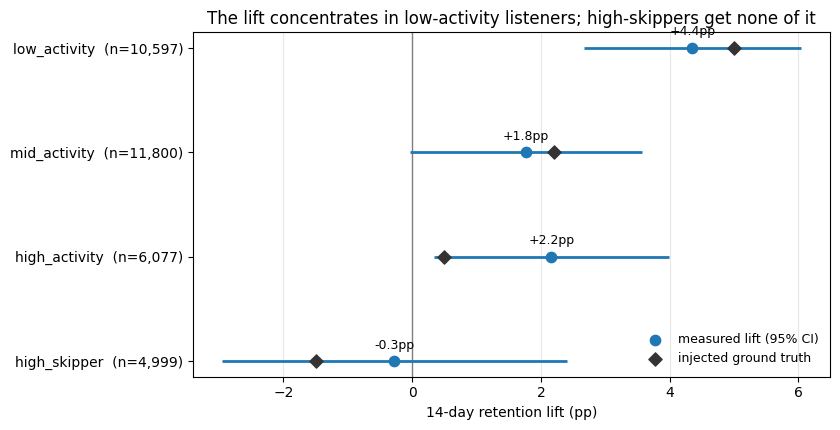

In [14]:
segment_order = ["low_activity", "mid_activity", "high_activity", "high_skipper"]
PRIMARY_SPEC = [MetricSpec("retention_14d", "retained_14d_post",
                           "proportion", "primary", "increase")]

seg_rows = []
for segment in segment_order:
    seg_df = results[results["effect_segment"] == segment]
    row = summarize_experiment(seg_df, PRIMARY_SPEC).iloc[0]
    seg_rows.append({
        "segment": segment,
        "n_users": len(seg_df),
        "measured_lift_pp": row["lift_abs"] * 100,
        "ci_low_pp": row["ci_low"] * 100,
        "ci_high_pp": row["ci_high"] * 100,
        "p_value": row["p_value"],
        "true_uplift_pp": SEGMENT_UPLIFT_PP[segment],
    })
segment_scorecard = pd.DataFrame(seg_rows)
print(segment_scorecard.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
y = np.arange(len(segment_scorecard))[::-1]
ax.axvline(0, color=NEUTRAL_COLOR, linewidth=1)
ax.hlines(y, segment_scorecard["ci_low_pp"].to_numpy(),
          segment_scorecard["ci_high_pp"].to_numpy(),
          color=CONTROL_COLOR, linewidth=2)
ax.scatter(segment_scorecard["measured_lift_pp"].to_numpy(), y,
           color=CONTROL_COLOR, s=55, zorder=3, label="measured lift (95% CI)")
ax.scatter(segment_scorecard["true_uplift_pp"].to_numpy(), y,
           color="#333333", marker="D", s=45, zorder=4, label="injected ground truth")
for yi, (_, row) in zip(y, segment_scorecard.iterrows()):
    ax.annotate(f"{row['measured_lift_pp']:+.1f}pp",
                xy=(row["measured_lift_pp"], yi), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}  (n={n:,})" for s, n in
                    zip(segment_scorecard["segment"], segment_scorecard["n_users"])])
ax.set_xlabel("14-day retention lift (pp)")
ax.set_title("The lift concentrates in low-activity listeners; "
             "high-skippers get none of it")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
extra_retained = primary.lift_abs * n_treatment
skip_row = guardrail_scorecard.set_index("metric").loc["skip_rate_14d"]
degraded_users = int(treatment["retained_14d_post"].sum())

print(f"Value side:  {primary.lift_abs*100:+.2f}pp retention "
      f"= ~{extra_retained:,.0f} extra retained users per {n_treatment:,} treated")
print(f"Cost side:   skip rate {skip_row['control']:.1%} -> {skip_row['treatment']:.1%} "
      f"({skip_row['lift_rel']:+.0%} relative) for all {degraded_users:,} "
      f"retained treated users")

Value side:  +2.58pp retention = ~429 extra retained users per 16,659 treated
Cost side:   skip rate 18.3% -> 20.6% (+13% relative) for all 7,969 retained treated users


**Launch framework** — the decision combines four independent checks, in order:

| Check | Result | Verdict |
|---|---|---|
| 1. Data quality (SRM, balance) | 50/50 split intact (p = 0.40), covariates balanced | ✅ |
| 2. Primary metric | +2.58pp retention, 95% CI [+1.5, +3.6]pp, p < 0.001 | ✅ |
| 3. Practical value | ~430 extra retained users per treated cohort; clears the +2pp launch bar | ✅ |
| 4. Guardrails | Skip rate **+13% relative (p < 0.001)** — breached. Cancels flat, ad revenue up | ❌ |

**Recommendation: do not fully launch.** Statistical significance is necessary but not sufficient — the module wins retention while measurably degrading listening quality for every retained treated user, and the segment view sharpens the diagnosis:

- **low_activity** users (32% of the population) capture nearly all the value (+4.4pp, the only decisively significant segment) — consistent with the discovery hypothesis.
- **high_skipper** users get nothing (−0.3pp measured, −1.5pp true) while already having the worst experience — the module amplifies what they dislike.
- Per-segment reads are directional, not confirmatory: with 5–12K users each, segment MDEs run 3–4pp, and the high_activity estimate (+2.2pp measured vs +0.5pp true) shows how far sampling noise moves a single segment cell.

**Next iteration:** fix recommendation quality until the skip-rate delta clears (tune ranking against skip feedback, especially for high-skip listeners), then retest; if the breach persists, evaluate a **targeted rollout** to low-activity users as its own pre-registered experiment rather than a post-hoc carve-out.

## 10. Key Findings

Experiment: personalized-playlist module vs existing home page, 33,473 non-paying users, user-level 50/50 randomization, 14-day retention primary. Simulated with known injected effects on the real population — the pipeline's job is to recover them.

- **The design is properly powered:** detecting a +2pp retention lift needs 9,762 users/arm; the population provides ~16.7K/arm, for an achievable MDE of 1.5pp.
- **Data quality gates passed:** SRM p = 0.40 (50/50 intact); all pre-period covariates balanced (|SMD| < 0.02). No result is readable before this line.
- **Primary recovered the truth:** measured +2.58pp (95% CI [+1.5, +3.6]pp, p < 0.001) against an injected +2.2pp population-weighted effect.
- **The behavioral chain is confirmatory:** listen minutes +10.2%, active days +9.8%, playlist-add rate +15.9% (all p < 0.001).
- **One guardrail breaks the launch:** skip rate 18.3% → 20.6% (+13% relative, p < 0.001); trial cancels flat (p = 0.38); ad revenue +6.7%. **Recommendation: iterate on recommendation quality and retest — do not fully launch.**
- **The win is concentrated:** low-activity listeners gain +4.4pp (95% CI [+2.7, +6.0]); high-skippers gain nothing (−0.3pp measured, −1.5pp injected). Segment reads beyond that are directional — per-segment MDEs run 3–4pp.
- **Pitfalls, quantified on this data:** daily peeking inflates the false-positive rate from 5% to ~20%; 6 of 50 zero-effect segment×metric tests look "significant" until Benjamini-Hochberg removes all 6; a week-1-only readout (+15% measured) overstates the +5% long-run engagement effect ~3x.

**Caveats.** Treatment effects are simulated (injected on real user covariates), so magnitudes validate the *method*, not the product idea; post-period engagement is proxied from pre-period behavior scaled with noise; enrollment is a single snapshot, so no true new-user cohort exists (minimum tenure 18 days) — in production this experiment would enroll new signups on a rolling basis. Ground-truth per-user uplift is stored in `data/experiment_results.csv.gz` (`true_uplift_pp`) for a future uplift-modeling notebook.